## Desafio 1

In [19]:
from tensorflow.keras import layers, models, Input
model_cnn = models.Sequential([
    Input(shape=(28, 28, 1)), # Adiciona a camada Input explicitamente
    layers.Conv2D(32, (3, 3), activation='relu'), # Remove input_shape da Conv2D
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [20]:
import tensorflow as tf
mnist = tf.keras.datasets.mnist
(x_train_m, y_train_m), (x_test_m, y_test_m) = mnist.load_data()
# Normalização base (valores entre 0 e 1)
x_train_m = x_train_m.astype('float32') / 255.0
x_test_m = x_test_m.astype('float32') / 255.0
# Remodelar os dados para incluir o canal (esperado por Conv2D)
x_train_m = x_train_m.reshape(x_train_m.shape[0], 28, 28, 1)
x_test_m = x_test_m.reshape(x_test_m.shape[0], 28, 28, 1)

In [21]:
import numpy as np # Importar numpy para np.argmax
from sklearn.metrics import classification_report # Importar para o classification_report

model_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_cnn.summary()
try:
    hist_cnn = model_cnn.fit(x_train_m, y_train_m, epochs=30, validation_split=0.1, verbose=1)

    # Fazer previsões no conjunto de testes
    y_pred_cnn_probs = model_cnn.predict(x_test_m)
    y_pred_cnn = np.argmax(y_pred_cnn_probs, axis=1)

    # Gerar e imprimir o classification report
    print("\nClassification Report para o Modelo CNN:")
    print(classification_report(y_test_m, y_pred_cnn, digits=4))

except Exception as e:
    print(f"Erro durante o treinamento: {e}")

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9450 - loss: 0.1858 - val_accuracy: 0.9812 - val_loss: 0.0681
Epoch 2/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9807 - loss: 0.0624 - val_accuracy: 0.9863 - val_loss: 0.0499
Epoch 3/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9872 - loss: 0.0412 - val_accuracy: 0.9870 - val_loss: 0.0471
Epoch 4/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9909 - loss: 0.0287 - val_accuracy: 0.9883 - val_loss: 0.0465
Epoch 5/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9926 - loss: 0.0215 - val_accuracy: 0.9870 - val_loss: 0.0567
Epoch 6/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9957 - loss: 0.0134 - val_accuracy: 0.9860 - val_loss: 0.0589
Epoch 7/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9966 - loss: 0.0107 - val_accuracy: 0.9885 - val_loss: 0.0547
Epoch 8/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9972 - loss: 0.0083 -

## Desafio 2

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.4779 - loss: 1.4450 - val_accuracy: 0.5928 - val_loss: 1.1361
Epoch 2/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6450 - loss: 1.0091 - val_accuracy: 0.6910 - val_loss: 0.9090
Epoch 3/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7061 - loss: 0.8394 - val_accuracy: 0.6822 - val_loss: 0.9051
Epoch 4/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7499 - loss: 0.7216 - val_accuracy: 0.7208 - val_loss: 0.8150
Epoch 5/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7815 - loss: 0.6250 - val_accuracy: 0.7384 - val_loss: 0.7921
Epoch 6/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8084 - loss: 0.5488 - val_accuracy: 0.7286 - val_loss: 0.7976
Epoch 7/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8331 - loss: 0.4766 - val_accuracy: 0.7430 - val_loss: 0.8177
Epoch 8/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8567 - loss: 0.4113 

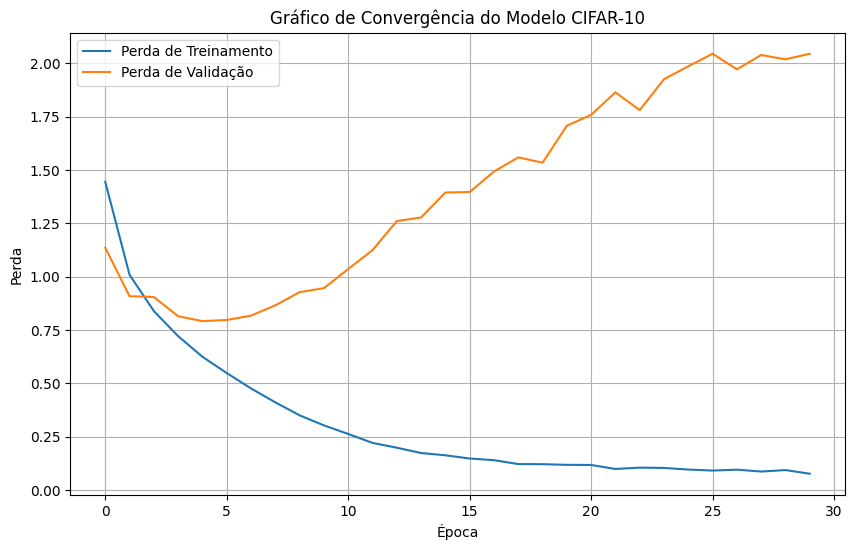

In [22]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input
import numpy as np
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

cifar10 = tf.keras.datasets.cifar10
(x_train_c, y_train_c), (x_test_c, y_test_c) = cifar10.load_data()
# Normalização de Tensores RGB
x_train_c, x_test_c = x_train_c / 255.0, x_test_c / 255.0

# Definição do modelo CNN para CIFAR-10
model_cifar = models.Sequential([
    Input(shape=(32, 32, 3)), # Imagens CIFAR-10 são 32x32 com 3 canais (RGB)
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax') # 10 classes para CIFAR-10
])

# Compilação do modelo
model_cifar.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model_cifar.summary()

# Treinamento do modelo
try:
    hist_cifar = model_cifar.fit(x_train_c, y_train_c, epochs=30, validation_split=0.1, verbose=1)

    # Fazer previsões no conjunto de testes
    y_pred_cifar_probs = model_cifar.predict(x_test_c)
    y_pred_cifar = np.argmax(y_pred_cifar_probs, axis=1)

    # Gerar e imprimir o classification report
    print("\nClassification Report para o Modelo CIFAR-10:")
    print(classification_report(y_test_c, y_pred_cifar, digits=4))

    # Gerar gráfico de convergência (perda de treinamento e validação)
    plt.figure(figsize=(10, 6))
    plt.plot(hist_cifar.history['loss'], label='Perda de Treinamento')
    plt.plot(hist_cifar.history['val_loss'], label='Perda de Validação')
    plt.title('Gráfico de Convergência do Modelo CIFAR-10')
    plt.xlabel('Época')
    plt.ylabel('Perda')
    plt.legend()
    plt.grid(True)
    plt.show()

except Exception as e:
    print(f"Erro durante o treinamento do modelo CIFAR-10: {e}")

## Desafio 3

In [23]:
import medmnist
from medmnist import INFO
data_flag = 'pathmnist'
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])
train_dataset = DataClass(split='train', download=True)
test_dataset = DataClass(split='test', download=True)

In [24]:
from tensorflow.keras import layers, models, Input

# Definição do modelo MLP
model_mlp = models.Sequential([
    Input(shape=(28, 28)), # A camada de entrada para imagens 28x28 (sem canal para MLP simples)
    layers.Flatten(),       # Achata a imagem para um vetor
    layers.Dense(128, activation='relu'), # Camada oculta com 128 neurônios
    layers.Dense(10, activation='softmax')  # Camada de saída para 10 classes
])

model_mlp.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import numpy as np # Necessário para np.argmax
from sklearn.metrics import classification_report # Importar para o classification_report
import matplotlib.pyplot as plt # Importar para os gráficos

# Se você for usar os dados MNIST (x_train_m, y_train_m),
# eles precisam ser remodelados de volta para 2D para o MLP.
# Se você já os carregou e remodelou para CNN (28,28,1),
# precisará usar uma versão 2D para o MLP ou remodelar aqui:

x_train_mlp = x_train_m.reshape(x_train_m.shape[0], 28, 28)
x_test_mlp = x_test_m.reshape(x_test_m.shape[0], 28, 28)

model_mlp.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

try:
    history = model_mlp.fit(x_train_mlp, y_train_m, epochs=30, validation_split=0.1, verbose=1)

    y_pred_mlp_probs = model_mlp.predict(x_test_mlp)
    y_pred_mlp = np.argmax(y_pred_mlp_probs, axis=1)
    print("\nClassification Report para o Modelo MLP:")
    print(classification_report(y_test_m, y_pred_mlp, digits=4))

    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Perda de Treinamento')
    plt.plot(history.history['val_loss'], label='Perda de Validação')
    plt.title('Gráfico de Convergência do Modelo MLP')
    plt.xlabel('Época')
    plt.ylabel('Perda')
    plt.legend()
    plt.grid(True)
    plt.show()

except Exception as e:
    print(f"Erro durante o treinamento do modelo MLP: {e}")

Epoch 1/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9220 - loss: 0.2712 - val_accuracy: 0.9657 - val_loss: 0.1239
Epoch 2/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9641 - loss: 0.1193 - val_accuracy: 0.9717 - val_loss: 0.1005
Epoch 3/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9750 - loss: 0.0825 - val_accuracy: 0.9747 - val_loss: 0.0918
Epoch 4/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9815 - loss: 0.0597 - val_accuracy: 0.9773 - val_loss: 0.0811
Epoch 5/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9866 - loss: 0.0457 - val_accuracy: 0.9788 - val_loss: 0.0781
Epoch 6/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9889 - loss: 0.0367 - val_accuracy: 0.9780 - val_loss: 0.0795
Epoch 7/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9909 - loss: 0.0283 - val_accuracy: 0.9805 - val_loss: 0.0771
Epoch 8/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9930 - loss: 0.0238 - 